# Analysis of data for the Essential FFPE Panel

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

from tqdm import trange

### BatchDetect module imports

Import project-specific helpers from the `batchdetect` package:

- `load_thal_cross_lot_covs` and related loaders for Thalassemia data.
- `HeavyMixture` and `parametric_bootstrap_lrt` for mixture modeling and
  parametric bootstrap-based likelihood ratio tests.
- Correlation-based clustering utilities:
  `cluster_hierarchical_corr`, `cluster_spectral_corr`,
  `cluster_pca_kmeans_corr`.
- Correlation preprocessing helpers: `normalize_mat` and `get_correlations`.

These functions implement the main batch-detection and clustering methods used
throughout the analysis.


In [5]:
from batchdetect.loader import load_essential_ffpe
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

In [3]:
df_thal_likelihoods = pd.read_csv('../likelihoods_essential.csv')
print(df_thal_likelihoods.head())
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

                                         Sample Name  Likelihood  Label
0  RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_20ng  -45.592543      0
1  RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_40ng  -28.952638      0
2  RDvSMpEssentialLBxd250509iN4-06B_PC2504014T15_...  -23.703107      0
3  RDvSMpEssentialLBxd250509iN4-06C_PC2504014T30_...  -27.889823      0
4  RDvSMpEssentialLBxd250509iN4-06D_PC2504015T1_20ng -114.047653      0


### Load  count data and metadata

Load the cross-lot coverage
matrix and associated metadata:

- `counts_thal`: amplicon-level coverage counts per sample.
- `y_thal`: sample labels from the loader (if provided).
- `sample_id`: sample identifiers.
- `features`: amplicon/feature annotations.

These raw counts are used for correlation-based clustering and neighborhood
analysis.


In [6]:
counts_thal,y_thal,sample_id,features,_ = load_essential_ffpe()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

In [7]:
index_homozygous_del = []
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_new = np.delete(likelihoods, index_homozygous_del)
y_new = np.delete(y_hat, index_homozygous_del)
snames_new = np.delete(snames,index_homozygous_del)

In [40]:
def null_factory():
    return HeavyMixture(
                n_components=1,
                component_distribution='gaussian',
                n_init=3,
                max_iter=1000,
            )   

def alt_factory():
            return HeavyMixture(
                n_components=2,
                component_distribution='gaussian',
                n_init=3,
                max_iter=1000,
            )   

In [30]:
n_rep = 3
rng = np.random.default_rng(2021)
res_list = []
for i in trange(n_rep):
    idx = rng.choice(len(y_new),replace=True,size=len(y_new))
    X_sub = likelihoods_new[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list.append(res)

100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:13<00:00,  4.60s/it]


In [32]:
print([res['p_value'] for res in res_list])

[np.float64(0.033932135728542916), np.float64(0.031936127744510975), np.float64(0.021956087824351298)]


In [52]:
like_pos = likelihoods_new[y_new==0]
like_pos

array([ -45.59254286,  -28.95263799,  -23.70310699,  -27.88982328,
       -114.0476528 , -110.2029116 , -106.8724478 , -101.0936212 ,
        -64.03203689,  -83.19283904,  -37.9489176 ,  -48.2335613 ,
        -70.14199405,  -46.6342677 , -115.1389336 ,  -92.5454416 ,
        -99.58526331, -138.6893412 ,   -6.52327877,   21.74266995,
        -87.98327303,  -63.41012292])

In [53]:
snames_pos = snames_new[y_new==0]
idx_sort = np.argsort(like_pos)
snames_pos[idx_sort]

array(['RDvSMpEssentialLBxd250509iN4-09C_PC2504006T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08H_PC2504005T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-06D_PC2504015T1_20ng',
       'RDvSMpEssentialLBxd250509iN4-06E_PC2504015T1_40ng',
       'RDvSMpEssentialLBxd250509iN4-06F_PC2504015T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-06G_PC2504015T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-09B_PC2504006T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-09A_PC2504005T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-09F_PC2504008T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-08C_PC2504002T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08F_PC2504004T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-08B_PC2504002T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-09G_PC2504008T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08E_PC2504003T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08G_PC2504004T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_20ng',
       'RDvSMpEssentialLBxd

In [54]:
snames_new[y_new==0]

array(['RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_20ng',
       'RDvSMpEssentialLBxd250509iN4-06A_PC2504014T1_40ng',
       'RDvSMpEssentialLBxd250509iN4-06B_PC2504014T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-06C_PC2504014T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-06D_PC2504015T1_20ng',
       'RDvSMpEssentialLBxd250509iN4-06E_PC2504015T1_40ng',
       'RDvSMpEssentialLBxd250509iN4-06F_PC2504015T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-06G_PC2504015T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08B_PC2504002T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-08C_PC2504002T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08D_PC2504003T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-08E_PC2504003T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08F_PC2504004T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-08G_PC2504004T30_40ng',
       'RDvSMpEssentialLBxd250509iN4-08H_PC2504005T15_40ng',
       'RDvSMpEssentialLBxd250509iN4-09A_PC2504005T30_40ng',
       'RDvSMpEssentialLBxd2

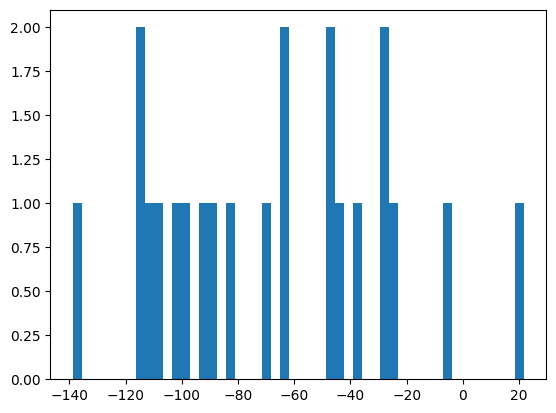

In [55]:
plt.hist(like_pos,50);

In [59]:
n_rep = 100
rng = np.random.default_rng(2021)
res_list_pos = []
for i in trange(n_rep):
    idx = rng.choice(len(like_pos),replace=True,size=int(.99*len(like_pos)))
    X_sub = like_pos[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list_pos.append(res)

100%|████████████████████████████████████████████████████████████████████| 100/100 [09:01<00:00,  5.42s/it]


In [63]:
a = np.array([res['p_value'] for res in res_list_pos])
print(np.array([res['p_value'] for res in res_list_pos]))

[0.0259481  0.14171657 0.18363273 0.62275449 0.04590818 0.06986028
 0.17165669 0.04590818 0.18962076 0.0758483  0.16566866 0.0998004
 0.09381238 0.10778443 0.05189621 0.0998004  0.23353293 0.00199601
 0.6007984  0.43313373 0.28343313 0.52295409 0.0239521  0.17165669
 0.8762475  0.00199601 0.16367265 0.02195609 0.14371257 0.86227545
 0.55489022 0.2255489  0.07185629 0.08982036 0.44710579 0.34730539
 0.5508982  0.10179641 0.34530938 0.12974052 0.93213573 0.97205589
 0.06586826 0.28742515 0.39720559 0.77245509 0.11576846 0.44111776
 0.06187625 0.03992016 0.98003992 0.4011976  0.4251497  0.9261477
 0.06387226 0.37325349 0.18762475 0.23752495 0.57884232 0.99600798
 0.10179641 0.34331337 0.06387226 0.36926148 0.26347305 0.12774451
 0.23752495 0.12974052 0.06586826 0.17165669 0.0259481  0.27145709
 0.19361277 0.06187625 0.24151697 0.16167665 0.56287425 0.00199601
 0.50698603 0.47904192 0.20758483 0.04590818 0.23952096 0.03193613
 0.38722555 0.04191617 0.77045908 0.50898204 0.56686627 0.225548

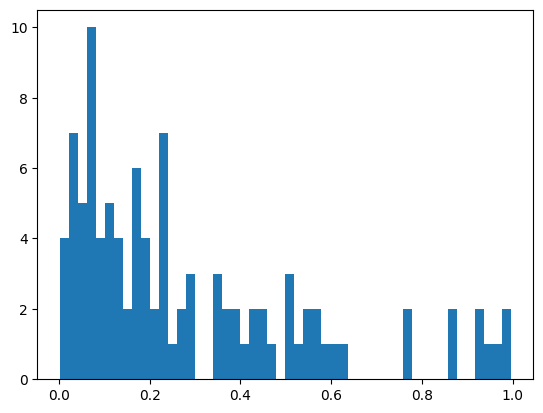

In [65]:
plt.hist(a,50);

In [66]:
np.sum(a<.05)

np.int64(15)